# Multidimensional Calculator Modeling with YAML Configuration

## Advanced System Dynamics with Calculator Components

This notebook demonstrates the powerful **Calculator** component in the System Dynamics Toolkit, showcasing how to perform arithmetic operations on multidimensional flows and stocks using YAML configuration files.

### Key Features Demonstrated:
- 🧮 **Calculator Components**: Arithmetic combinations of flows and stocks
- 📊 **Multidimensional Operations**: Array operations across age, income, and region dimensions
- 🔗 **Dependency Resolution**: Automatic handling of calculator-to-calculator dependencies
- 📈 **Population Analytics**: Demographic calculations and dependency ratios
- 🌍 **Climate Adaptation**: Migration and growth flow calculations
- 📋 **YAML Configuration**: Declarative model definition with calculator expressions

### Calculator Types Showcased:
1. **Flow Combinations**: Net migration = immigration - emigration
2. **Growth Calculations**: Natural growth = births - deaths
3. **Population Aggregations**: Urban/rural totals using np.sum operations
4. **Demographic Indicators**: Dependency ratios and age structure analysis
5. **Validation Checks**: Cross-verification of population totals

---

## Section 0: Kernel Restart Helper (Run if needed)

If you encounter module import issues, run this cell to clear the module cache.

In [49]:
# Restart kernel and reload modules if needed
import sys
import importlib

# Clear module cache for sd_toolkit
modules_to_reload = [name for name in sys.modules.keys() if name.startswith('sd_toolkit')]
for module_name in modules_to_reload:
    if module_name in sys.modules:
        del sys.modules[module_name]

print(f"🔄 Cleared {len(modules_to_reload)} sd_toolkit modules from cache")
print("✅ Ready to re-import updated modules")
print("\n💡 TIP: If you still get errors, restart the kernel completely:")
print("   Kernel → Restart Kernel (or Ctrl+. in VS Code)")

🔄 Cleared 15 sd_toolkit modules from cache
✅ Ready to re-import updated modules

💡 TIP: If you still get errors, restart the kernel completely:
   Kernel → Restart Kernel (or Ctrl+. in VS Code)


## Section 1: Environment Setup and Toolkit Imports

Setting up the environment with all necessary imports for calculator demonstrations.

In [50]:
# Standard scientific computing imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xarray as xr
from pathlib import Path
import yaml
import warnings
warnings.filterwarnings('ignore')

# Set plotting style for publication-quality figures
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11

# Add the sd_toolkit to the path
import sys
import os
sys.path.insert(0, os.path.join('..', '..', 'sd_toolkit'))

# Import System Dynamics Toolkit components
from sd_toolkit.config import YAMLSystemBuilder, TemplateManager, rate_registry
from sd_toolkit.engine.system import SystemModel
from sd_toolkit.engine.elements import Stock, Flow, Auxiliary, Calculator
from sd_toolkit.data.loader import SpatioTemporalData
from sd_toolkit.analysis.plotting import SystemPlotter
from sd_toolkit.core.units import Q_, unit_registry

print("✅ System Dynamics Toolkit loaded successfully!")
print("🧮 Calculator components ready for demonstration")
print(f"📊 Available rate functions: {len(rate_registry.list_functions())}")

✅ System Dynamics Toolkit loaded successfully!
🧮 Calculator components ready for demonstration
📊 Available rate functions: 3


## Section 2: Load and Examine Calculator Model YAML

Loading the multidimensional calculator example and examining its structure, focusing on the calculator definitions.

In [51]:
# Define path to the calculator example YAML
calculator_model_path = Path('calculator_model_structure.yaml')

# Load calculator model configuration
print("📂 Loading multidimensional calculator model...")
with open(calculator_model_path, 'r') as file:
    calculator_config = yaml.safe_load(file)

print(f"✅ Model loaded: {calculator_config['model']['name']}")
print(f"📝 Description: {calculator_config['model']['description']}")
print(f"⏱️ Time horizon: {calculator_config['model']['time_horizon']} {calculator_config['model']['time_units']}")
print(f"🔢 Time step: {calculator_config['model']['dt']} {calculator_config['model']['time_units']}")

# Display dimension specifications
print("\n🏗️ MODEL DIMENSIONS:")
print("=" * 50)
dimensions = calculator_config['dimensions']
for dim_name, dim_spec in dimensions.items():
    print(f"\n📊 {dim_name.upper()}:")
    print(f"   Size: {dim_spec['size']}")
    print(f"   Labels: {dim_spec['labels']}")

# Display model elements summary
elements = calculator_config['elements']
print(f"\n🧩 MODEL ELEMENTS:")
print("=" * 50)
print(f"📦 Stocks: {len(elements['stocks'])}")
print(f"🌊 Flows: {len(elements['flows'])}")
print(f"🧮 Calculators: {len(elements['calculators'])}")
print(f"🔗 Connections: {len(calculator_config['connections'])}")

# Highlight calculator definitions
calculators = elements['calculators']
print(f"\n🧮 CALCULATOR DEFINITIONS: {len(calculators)}")
print("=" * 60)
for i, calc in enumerate(calculators, 1):
    print(f"\n{i}. 🧮 {calc['name']}:")
    print(f"   Expression: {calc['expression']}")
    print(f"   Units: {calc['units']}")
    print(f"   Description: {calc['description']}")
    if 'spatial_dims' in calc:
        print(f"   Spatial Dims: {calc['spatial_dims']}")
    if 'dependencies' in calc:
        print(f"   Dependencies: {calc['dependencies']}")

📂 Loading multidimensional calculator model...
✅ Model loaded: Multidimensional Population Model with Calculators
📝 Description: Climate adaptation model with multidimensional calculators
⏱️ Time horizon: 50 year
🔢 Time step: 1 year

🏗️ MODEL DIMENSIONS:

📊 AGE_GROUP:
   Size: 3
   Labels: ['young_0_18', 'adult_19_65', 'elderly_65_plus']

📊 INCOME_LEVEL:
   Size: 3
   Labels: ['low_income', 'medium_income', 'high_income']

📊 REGION:
   Size: 2
   Labels: ['urban', 'rural']

🧩 MODEL ELEMENTS:
📦 Stocks: 1
🌊 Flows: 4
🧮 Calculators: 10
🔗 Connections: 1

🧮 CALCULATOR DEFINITIONS: 10

1. 🧮 Net_Migration_Flow:
   Expression: 4 * Economic_Migration_In - Climate_Migration_Out
   Units: people/year
   Description: Net migration = economic in-migration - climate out-migration
   Spatial Dims: ['age_group', 'income_level', 'region']
   Dependencies: ['Economic_Migration_In', 'Climate_Migration_Out']

2. 🧮 Natural_Growth_Flow:
   Expression: Birth_Flow - Death_Flow
   Units: people/year
   Descript

## Section 3: Build Model with Calculator Components

Creating the system dynamics model using YAMLSystemBuilder and examining the instantiated calculator objects.

In [52]:
# Build the model using YAMLSystemBuilder
print("🏗️ Building multidimensional calculator model...")

try:
    builder = YAMLSystemBuilder()
    calculator_model = builder.build_from_dict(calculator_config)
    
    print(f"✅ Model built successfully: {calculator_model.name}")
    print(f"📊 Total elements: {len(calculator_model.elements)}")
    print(f"📦 Stocks: {len(calculator_model.stocks)}")
    print(f"🌊 Flows: {len(calculator_model.flows)}")
    print(f"🧮 Calculators: {len(calculator_model.calculators)}")
    
    # Validate model dimensions
    if hasattr(calculator_model, 'dimensions'):
        print(f"\n🏗️ Model dimensions: {list(calculator_model.dimensions.keys())}")
        
        # Check population stock dimensions
        population_stock = None
        for stock_id, stock in calculator_model.stocks.items():
            if stock.name == 'Population':
                population_stock = stock
                break
        
        if population_stock:
            pop_shape = np.array(population_stock.initial_value).shape
            expected_shape = tuple(dim['size'] for dim in calculator_model.dimensions.values())
            
            print(f"📊 Population shape: {pop_shape}")
            print(f"📊 Expected shape: {expected_shape}")
            
            if pop_shape == expected_shape:
                print("✅ Dimension validation passed!")
            else:
                print("❌ Dimension mismatch detected!")
    
except Exception as e:
    print(f"❌ Error building model: {e}")
    import traceback
    traceback.print_exc()
    calculator_model = None

🏗️ Building multidimensional calculator model...
✅ Model built successfully: Multidimensional Population Model with Calculators
📊 Total elements: 15
📦 Stocks: 1
🌊 Flows: 4
🧮 Calculators: 10

🏗️ Model dimensions: ['age_group', 'income_level', 'region']
📊 Population shape: (3, 3, 2)
📊 Expected shape: (3, 3, 2)
✅ Dimension validation passed!


## Section 4: Examine Calculator Objects and Dependencies

Detailed examination of the instantiated calculator objects, their dependencies, and expressions.

In [53]:
# Display detailed calculator information
if calculator_model is not None:
    print("🧮 DETAILED CALCULATOR ANALYSIS")
    print("=" * 60)
    
    for calc_id, calculator in calculator_model.calculators.items():
        print(f"\n📊 Calculator: {calculator.name}")
        print(f"   ID: {calc_id}")
        print(f"   Expression: {calculator.expression}")
        print(f"   Units: {calculator.units}")
        print(f"   Description: {calculator.description}")
        
        if hasattr(calculator, 'spatial_dims') and calculator.spatial_dims:
            print(f"   Spatial Dimensions: {calculator.spatial_dims}")
        
        # Show dependency information
        print(f"   Expected Dependencies: {calculator.dependency_names}")
        print(f"   Resolved Dependencies ({len(calculator.dependencies)}):")
        for dep in calculator.dependencies:
            dep_type = type(dep).__name__
            print(f"     - {dep.name}: {dep_type} ({dep.units})")
        
        # Check if all dependencies are resolved
        expected_deps = set(calculator.dependency_names)
        resolved_deps = set(dep.name for dep in calculator.dependencies)
        missing_deps = expected_deps - resolved_deps
        
        if missing_deps:
            print(f"   ❌ Missing Dependencies: {missing_deps}")
        else:
            print(f"   ✅ All dependencies resolved")
    
    # Display model structure summary
    print("\n🧩 MODEL STRUCTURE SUMMARY:")
    print("=" * 50)

    print("\n📦 STOCKS:")
    for stock_id, stock in calculator_model.stocks.items():
        shape = np.array(stock.initial_value).shape if hasattr(stock.initial_value, 'shape') else 'scalar'
        print(f"  • {stock.name}: {stock.units} (shape: {shape})")
        print(f"    Description: {stock.description}")

    print("\n🌊 FLOWS:")
    for flow_id, flow in calculator_model.flows.items():
        print(f"  • {flow.name}: {flow.units}")
        print(f"    Description: {flow.description}")
        if hasattr(flow, 'spatial_dims') and flow.spatial_dims:
            print(f"    Spatial Dims: {flow.spatial_dims}")

    print("\n🧮 CALCULATORS:")
    for calc_id, calc in calculator_model.calculators.items():
        print(f"  • {calc.name}: {calc.units}")
        print(f"    Expression: {calc.expression}")
        if hasattr(calc, 'spatial_dims') and calc.spatial_dims:
            print(f"    Spatial Dims: {calc.spatial_dims}")
else:
    print("❌ No model available to analyze")

🧮 DETAILED CALCULATOR ANALYSIS

📊 Calculator: Net_Migration_Flow
   ID: 867442ee-57f9-4ebf-80c0-a7754fab59bc
   Expression: 4 * Economic_Migration_In - Climate_Migration_Out
   Units: people/year
   Description: Net migration = economic in-migration - climate out-migration
   Spatial Dimensions: ['age_group', 'income_level', 'region']
   Expected Dependencies: ['Economic_Migration_In', 'Climate_Migration_Out']
   Resolved Dependencies (2):
     - Economic_Migration_In: Flow (people/year)
     - Climate_Migration_Out: Flow (people/year)
   ✅ All dependencies resolved

📊 Calculator: Natural_Growth_Flow
   ID: bbeb840e-3969-409c-8cfd-f20afe56eb57
   Expression: Birth_Flow - Death_Flow
   Units: people/year
   Description: Natural population growth = births - deaths
   Spatial Dimensions: ['age_group', 'income_level', 'region']
   Expected Dependencies: ['Birth_Flow', 'Death_Flow']
   Resolved Dependencies (2):
     - Birth_Flow: Flow (people/year)
     - Death_Flow: Flow (people/year)
   

## Section 5: Display Initial Conditions and Test Calculator Expressions

Examining the initial population distribution and testing calculator expressions with initial values.

In [54]:
# Extract and analyze initial population array
if calculator_model is not None:
    # Find population stock
    population_stock = None
    for stock_id, stock in calculator_model.stocks.items():
        if stock.name == 'Population':
            population_stock = stock
            break

    if population_stock is None:
        raise ValueError("Population stock not found in model")

    initial_population = np.array(population_stock.initial_value)

    print("👥 INITIAL POPULATION ANALYSIS")
    print("=" * 50)
    print(f"Total population: {initial_population.sum():,}")
    print(f"Array shape: {initial_population.shape}")
    print(f"Dimensions: {list(calculator_model.dimensions.keys())}")

    # Get dimension labels
    age_labels = calculator_model.dimensions['age_group']['labels']
    income_labels = calculator_model.dimensions['income_level']['labels']
    region_labels = calculator_model.dimensions['region']['labels']

    print("\nPopulation by Age Group:")
    for i, age_label in enumerate(age_labels):
        age_total = initial_population[i].sum()
        age_percent = (age_total / initial_population.sum()) * 100
        print(f"  {age_label}: {age_total:,} ({age_percent:.1f}%)")

    print("\nPopulation by Income Level:")
    for j, income_label in enumerate(income_labels):
        income_total = initial_population[:, j, :].sum()
        income_percent = (income_total / initial_population.sum()) * 100
        print(f"  {income_label}: {income_total:,} ({income_percent:.1f}%)")

    print("\nPopulation by Region:")
    for k, region_label in enumerate(region_labels):
        region_total = initial_population[:, :, k].sum()
        region_percent = (region_total / initial_population.sum()) * 100
        print(f"  {region_label}: {region_total:,} ({region_percent:.1f}%)")

    # Test calculator expressions with initial values
    print("\n🧮 TESTING CALCULATOR EXPRESSIONS AT t=0")
    print("=" * 60)
    
    for calc_id, calculator in calculator_model.calculators.items():
        try:
            # Calculate value at time 0
            result = calculator.calculate(time=0.0, dt=0.25)
            
            print(f"\n🧮 {calculator.name}:")
            print(f"   Expression: {calculator.expression}")
            
            if isinstance(result, np.ndarray):
                print(f"   Result: Array shape={result.shape}")
                print(f"   Total/Sum: {result.sum():.3f} {calculator.units}")
                print(f"   Range: [{result.min():.3f}, {result.max():.3f}]")
                
                # Show some sample values for multidimensional results
                if result.ndim > 0:
                    print(f"   Sample values: {result.flat[:3]}")
            else:
                print(f"   Result: {result:.6f} {calculator.units}")
                
        except Exception as e:
            print(f"\n🧮 {calculator.name}: ❌ Error - {e}")
else:
    print("❌ No model available for initial conditions analysis")

👥 INITIAL POPULATION ANALYSIS
Total population: 22,300
Array shape: (3, 3, 2)
Dimensions: ['age_group', 'income_level', 'region']

Population by Age Group:
  young_0_18: 8,300 (37.2%)
  adult_19_65: 10,800 (48.4%)
  elderly_65_plus: 3,200 (14.3%)

Population by Income Level:
  low_income: 8,800 (39.5%)
  medium_income: 7,100 (31.8%)
  high_income: 6,400 (28.7%)

Population by Region:
  urban: 11,400 (51.1%)
  rural: 10,900 (48.9%)

🧮 TESTING CALCULATOR EXPRESSIONS AT t=0

🧮 Net_Migration_Flow:
   Expression: 4 * Economic_Migration_In - Climate_Migration_Out
   Result: 0.000000 people/year

🧮 Natural_Growth_Flow:
   Expression: Birth_Flow - Death_Flow
   Result: 0.000000 people/year

🧮 Total_Population_Change:
   Expression: (Natural_Growth_Flow + Net_Migration_Flow) * Population
   Result: 0.000000 people/year

🧮 Urban_Population_Total:
   Expression: np.sum(Population[:, :, 0])
   Result: 11400.000000 people

🧮 Rural_Population_Total:
   Expression: np.sum(Population[:, :, 1])
   Resu

## Section 6: Run Simulation and Analyze Calculator Results

Running the simulation and examining how calculator values evolve over time.

In [55]:
# Run simulation with calculator model
if calculator_model is not None:
    print("🚀 Running calculator model simulation...")
    print(f"⏱️ Time horizon: {calculator_model.time_horizon} years")
    print(f"🔢 Time step: {calculator_model.dt} years")
    print(f"📊 Expected time points: {int(calculator_model.time_horizon / calculator_model.dt) + 1}")

    try:
        # Validate model before simulation
        validation = calculator_model.validate_model()
        if validation['valid']:
            print("✅ Model validation passed")
        else:
            print(f"⚠️ Model validation warnings: {validation['warnings']}")
        
        # Run simulation
        calculator_results = calculator_model.simulate(
            time_horizon=calculator_model.time_horizon,
            dt=calculator_model.dt
        )
        
        print(f"✅ Simulation completed successfully!")
        print(f"📊 Results shape: {calculator_results.shape}")
        print(f"📋 Variables: {list(calculator_results.columns)}")
        print(f"⏱️ Time range: {calculator_results['time'].min():.1f} to {calculator_results['time'].max():.1f} years")
        
        # Analyze calculator results
        print("\n🧮 CALCULATOR RESULTS ANALYSIS")
        print("=" * 60)
        
        calculator_columns = [col for col in calculator_results.columns 
                            if col in [calc.name for calc in calculator_model.calculators.values()]]
        
        print(f"📊 Calculator variables in results: {len(calculator_columns)}")
        
        for calc_name in calculator_columns:
            if calc_name in calculator_results.columns:
                initial_val = calculator_results[calc_name].iloc[0]
                final_val = calculator_results[calc_name].iloc[-1]
                mean_val = calculator_results[calc_name].mean()
                
                print(f"\n📈 {calc_name}:")
                print(f"   Initial: {initial_val:.3f}")
                print(f"   Final: {final_val:.3f}")
                print(f"   Mean: {mean_val:.3f}")
                print(f"   Change: {final_val - initial_val:+.3f} ({((final_val/initial_val - 1) * 100):+.1f}%)" 
                      if initial_val != 0 else f"   Change: {final_val - initial_val:+.3f}")
        
        # Population summary
        if 'Population' in calculator_results.columns:
            initial_pop = calculator_results['Population'].iloc[0]
            final_pop = calculator_results['Population'].iloc[-1]
            growth_rate = ((final_pop / initial_pop) ** (1/calculator_model.time_horizon) - 1) * 100
            
            print(f"\n📈 POPULATION SUMMARY:")
            print("=" * 50)
            print(f"Initial population: {initial_pop:,.0f}")
            print(f"Final population: {final_pop:,.0f}")
            print(f"Total change: {final_pop - initial_pop:+,.0f} ({((final_pop/initial_pop - 1) * 100):+.1f}%)")
            print(f"Annual growth rate: {growth_rate:+.2f}%")
        
        # Check for any issues in results
        if calculator_results.isnull().any().any():
            print("⚠️ Warning: NaN values detected in results")
        
        if (calculator_results.select_dtypes(include=[np.number]) < 0).any().any():
            negative_cols = calculator_results.select_dtypes(include=[np.number]).columns[
                (calculator_results.select_dtypes(include=[np.number]) < 0).any()]
            print(f"⚠️ Warning: Negative values detected in: {list(negative_cols)}")
        
    except Exception as e:
        print(f"❌ Error during simulation: {e}")
        import traceback
        traceback.print_exc()
        calculator_results = None
else:
    print("❌ No model available for simulation")
    calculator_results = None

🚀 Running calculator model simulation...
⏱️ Time horizon: 50 years
🔢 Time step: 1 years
📊 Expected time points: 51
✅ Model validation passed
✅ Simulation completed successfully!
📊 Results shape: (51, 16)
📋 Variables: ['time', 'Population', 'Birth_Flow', 'Death_Flow', 'Climate_Migration_Out', 'Economic_Migration_In', 'Net_Migration_Flow', 'Natural_Growth_Flow', 'Total_Population_Change', 'Urban_Population_Total', 'Rural_Population_Total', 'Total_Population_Check', 'Young_Population_Total', 'Working_Age_Population', 'Elderly_Population_Total', 'Dependency_Ratio']
⏱️ Time range: 0.0 to 50.0 years

🧮 CALCULATOR RESULTS ANALYSIS
📊 Calculator variables in results: 10

📈 Net_Migration_Flow:
   Initial: 0.007
   Final: 0.007
   Mean: 0.007
   Change: +0.000 (+0.0%)

📈 Natural_Growth_Flow:
   Initial: 0.010
   Final: 0.010
   Mean: 0.010
   Change: +0.000 (+0.0%)

📈 Total_Population_Change:
   Initial: 17.000
   Final: 17.000
   Mean: 17.000
   Change: +0.000 (+0.0%)

📈 Urban_Population_Total:


## Section 7: Visualize Calculator Results and Multidimensional Operations

Creating comprehensive visualizations to showcase calculator operations and their results.

🎨 Creating calculator results visualizations...


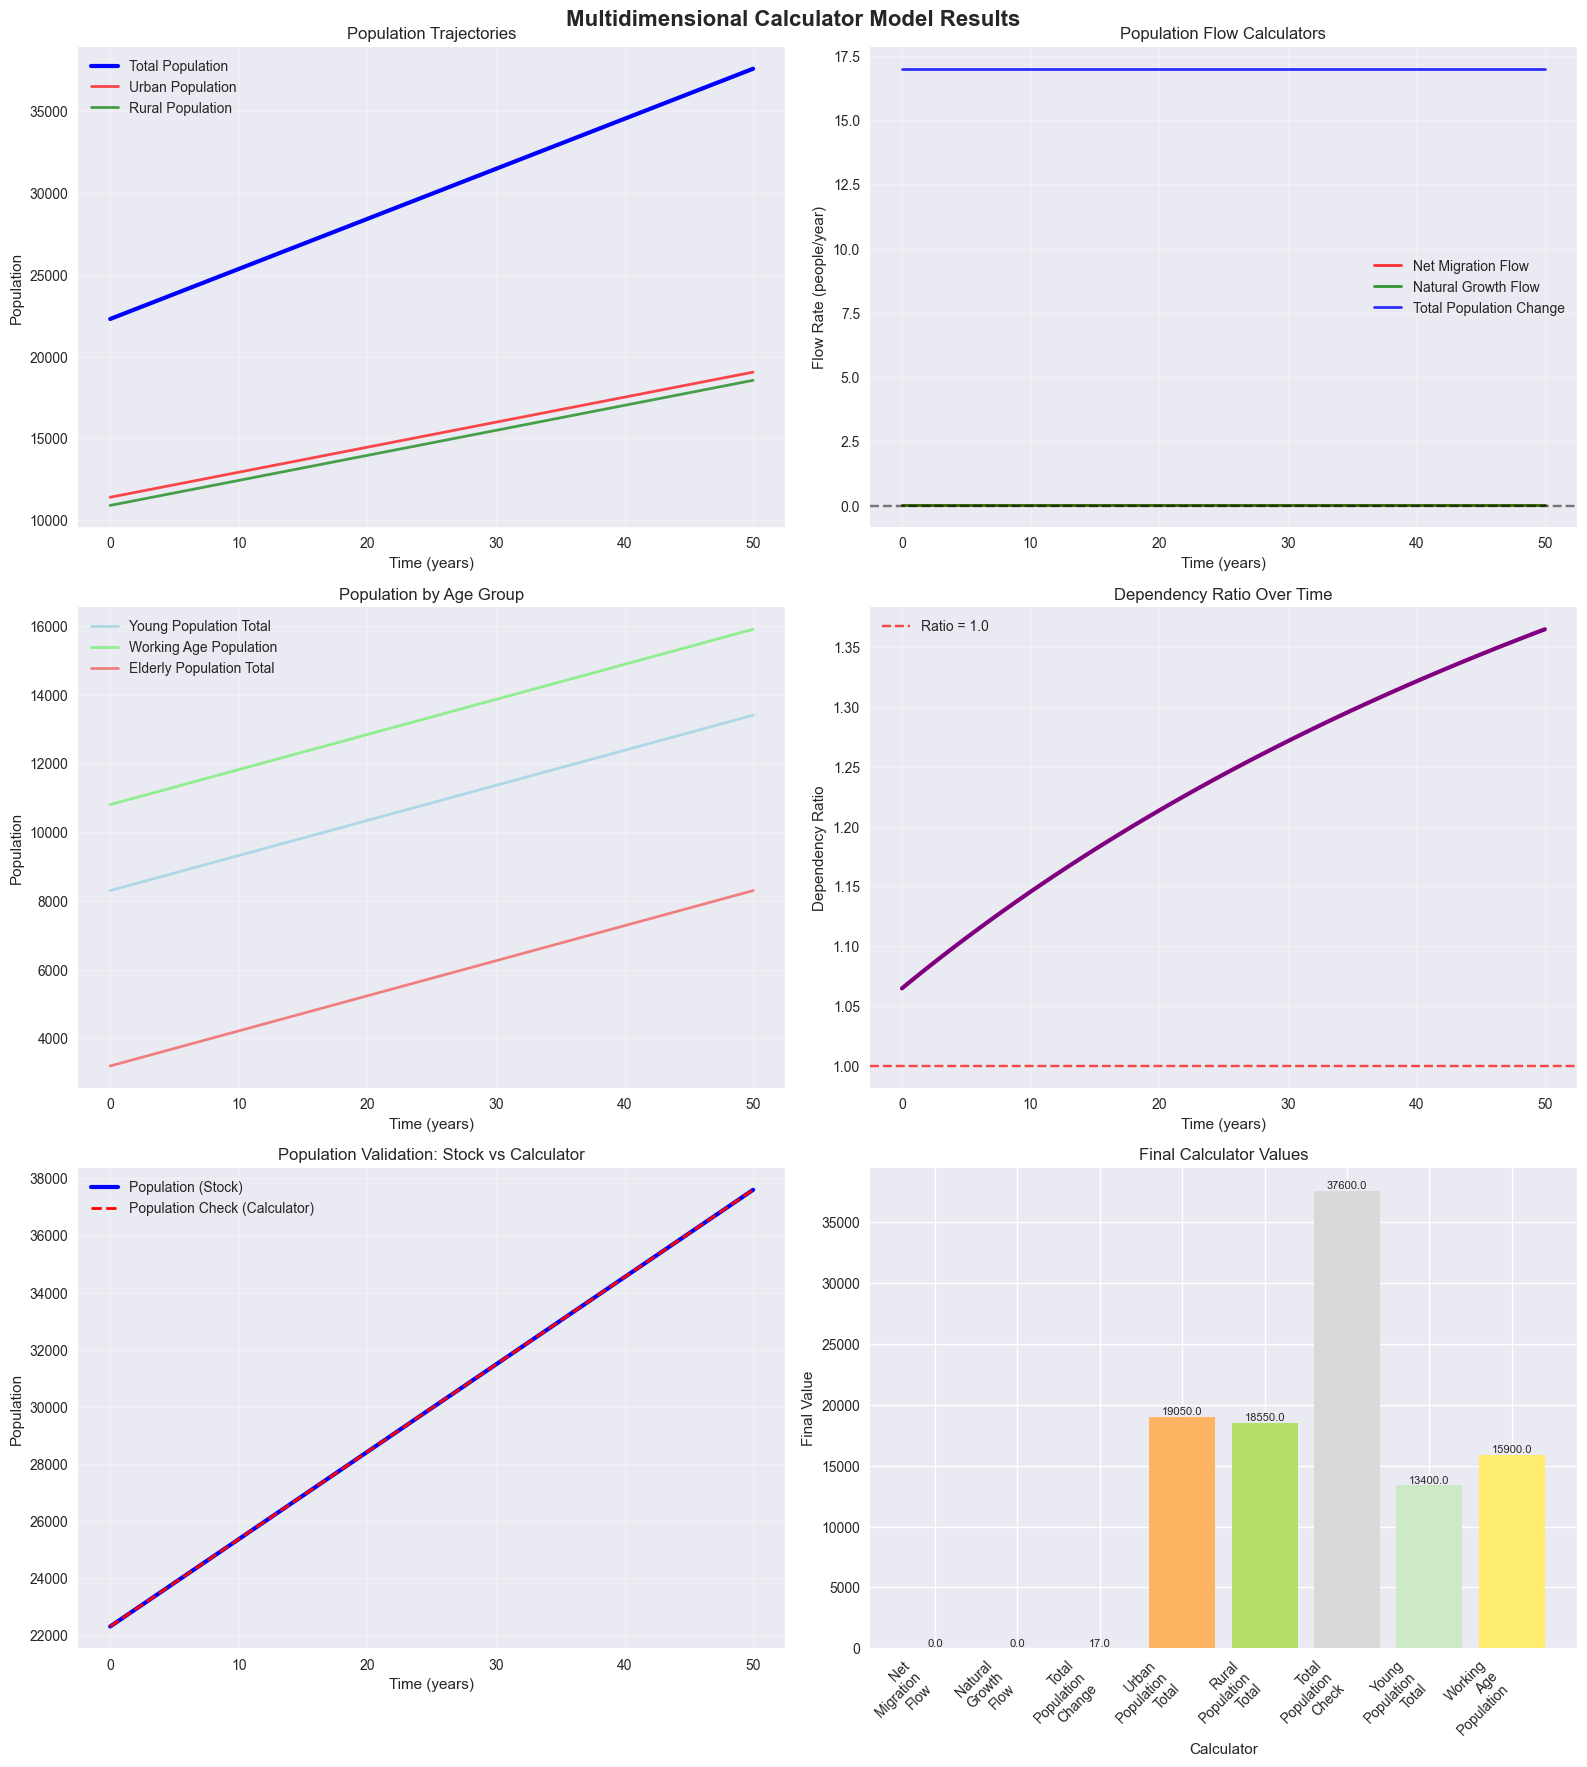

In [56]:
# Create comprehensive visualizations for calculator results
if calculator_results is not None and calculator_model is not None:
    print("🎨 Creating calculator results visualizations...")
    
    # Create a comprehensive dashboard
    fig, axes = plt.subplots(3, 2, figsize=(16, 18))
    fig.suptitle('Multidimensional Calculator Model Results', fontsize=16, fontweight='bold')
    
    # 1. Population and key calculators over time
    time_data = calculator_results['time']
    
    # Population trajectory
    if 'Population' in calculator_results.columns:
        axes[0, 0].plot(time_data, calculator_results['Population'], 
                       label='Total Population', linewidth=3, color='blue')
    
    # Add population totals by region if available
    if 'Urban_Population_Total' in calculator_results.columns:
        axes[0, 0].plot(time_data, calculator_results['Urban_Population_Total'], 
                       label='Urban Population', linewidth=2, color='red', alpha=0.7)
    if 'Rural_Population_Total' in calculator_results.columns:
        axes[0, 0].plot(time_data, calculator_results['Rural_Population_Total'], 
                       label='Rural Population', linewidth=2, color='green', alpha=0.7)
    
    axes[0, 0].set_title('Population Trajectories')
    axes[0, 0].set_xlabel('Time (years)')
    axes[0, 0].set_ylabel('Population')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. Flow calculators (Net Migration and Natural Growth)
    flow_calculators = ['Net_Migration_Flow', 'Natural_Growth_Flow', 'Total_Population_Change']
    colors = ['red', 'green', 'blue']
    
    for i, (calc_name, color) in enumerate(zip(flow_calculators, colors)):
        if calc_name in calculator_results.columns:
            axes[0, 1].plot(time_data, calculator_results[calc_name], 
                           label=calc_name.replace('_', ' '), linewidth=2, color=color, alpha=0.8)
    
    axes[0, 1].set_title('Population Flow Calculators')
    axes[0, 1].set_xlabel('Time (years)')
    axes[0, 1].set_ylabel('Flow Rate (people/year)')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].axhline(y=0, color='black', linestyle='--', alpha=0.5)
    
    # 3. Age structure calculators
    age_calculators = ['Young_Population_Total', 'Working_Age_Population', 'Elderly_Population_Total']
    age_colors = ['lightblue', 'lightgreen', 'lightcoral']
    
    for calc_name, color in zip(age_calculators, age_colors):
        if calc_name in calculator_results.columns:
            axes[1, 0].plot(time_data, calculator_results[calc_name], 
                           label=calc_name.replace('_', ' '), linewidth=2, color=color)
    
    axes[1, 0].set_title('Population by Age Group')
    axes[1, 0].set_xlabel('Time (years)')
    axes[1, 0].set_ylabel('Population')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # 4. Dependency ratio over time
    if 'Dependency_Ratio' in calculator_results.columns:
        axes[1, 1].plot(time_data, calculator_results['Dependency_Ratio'], 
                       linewidth=3, color='purple')
        axes[1, 1].set_title('Dependency Ratio Over Time')
        axes[1, 1].set_xlabel('Time (years)')
        axes[1, 1].set_ylabel('Dependency Ratio')
        axes[1, 1].grid(True, alpha=0.3)
        
        # Add reference line at 1.0
        axes[1, 1].axhline(y=1.0, color='red', linestyle='--', alpha=0.7, label='Ratio = 1.0')
        axes[1, 1].legend()
    
    # 5. Population validation check
    if 'Total_Population_Check' in calculator_results.columns and 'Population' in calculator_results.columns:
        # Plot both total population and the calculator check
        axes[2, 0].plot(time_data, calculator_results['Population'], 
                       label='Population (Stock)', linewidth=3, color='blue')
        axes[2, 0].plot(time_data, calculator_results['Total_Population_Check'], 
                       label='Population Check (Calculator)', linewidth=2, color='red', linestyle='--')
        
        axes[2, 0].set_title('Population Validation: Stock vs Calculator')
        axes[2, 0].set_xlabel('Time (years)')
        axes[2, 0].set_ylabel('Population')
        axes[2, 0].legend()
        axes[2, 0].grid(True, alpha=0.3)
    
    # 6. Calculator summary statistics
    calculator_names = [col for col in calculator_results.columns 
                       if col in [calc.name for calc in calculator_model.calculators.values()]]
    
    if calculator_names:
        # Calculate final values for each calculator
        final_values = [calculator_results[name].iloc[-1] for name in calculator_names[:8]]  # Limit to 8 for readability
        display_names = [name.replace('_', '\n') for name in calculator_names[:8]]
        
        bars = axes[2, 1].bar(range(len(final_values)), final_values, 
                             color=plt.cm.Set3(np.linspace(0, 1, len(final_values))))
        axes[2, 1].set_title('Final Calculator Values')
        axes[2, 1].set_xlabel('Calculator')
        axes[2, 1].set_ylabel('Final Value')
        axes[2, 1].set_xticks(range(len(display_names)))
        axes[2, 1].set_xticklabels(display_names, rotation=45, ha='right')
        
        # Add value labels on bars
        for bar, value in zip(bars, final_values):
            height = bar.get_height()
            axes[2, 1].text(bar.get_x() + bar.get_width()/2., height,
                           f'{value:.1f}', ha='center', va='bottom', fontsize=8)
    
    plt.tight_layout()
    plt.show()
    
else:
    print("❌ No simulation results available for visualization")

## Section 8: Calculator Insights and Multidimensional Analysis

Deep dive into calculator functionality and multidimensional operations.

In [57]:
# Detailed analysis of calculator functionality
if calculator_model is not None and calculator_results is not None:
    print("🔍 CALCULATOR INSIGHTS AND ANALYSIS")
    print("=" * 70)
    
    # 1. Demonstrate multidimensional indexing with calculators
    print("\n📊 MULTIDIMENSIONAL CALCULATOR OPERATIONS:")
    print("=" * 60)
    
    # Get dimension information
    age_labels = calculator_model.dimensions['age_group']['labels']
    income_labels = calculator_model.dimensions['income_level']['labels']
    region_labels = calculator_model.dimensions['region']['labels']
    
    print(f"Model dimensions: {list(calculator_model.dimensions.keys())}")
    print(f"Age groups: {age_labels}")
    print(f"Income levels: {income_labels}")
    print(f"Regions: {region_labels}")
    
    # Demonstrate calculator expressions that use multidimensional operations
    multidim_calculators = [
        ('Urban_Population_Total', 'np.sum(Population[:, :, 0])', 'Sums across age and income for urban region'),
        ('Rural_Population_Total', 'np.sum(Population[:, :, 1])', 'Sums across age and income for rural region'),
        ('Young_Population_Total', 'np.sum(Population[0, :, :])', 'Sums young population across income and region'),
        ('Working_Age_Population', 'np.sum(Population[1, :, :])', 'Sums adult population across income and region'),
        ('Elderly_Population_Total', 'np.sum(Population[2, :, :])', 'Sums elderly population across income and region')
    ]
    
    print("\n🧮 Multidimensional Calculator Examples:")
    for name, expression, description in multidim_calculators:
        if name in calculator_results.columns:
            initial_val = calculator_results[name].iloc[0]
            final_val = calculator_results[name].iloc[-1]
            print(f"\n• {name}:")
            print(f"  Expression: {expression}")
            print(f"  Purpose: {description}")
            print(f"  Initial value: {initial_val:,.0f}")
            print(f"  Final value: {final_val:,.0f}")
            print(f"  Change: {final_val - initial_val:+,.0f} ({((final_val/initial_val - 1) * 100):+.1f}%)")
    
    # 2. Calculator dependency analysis
    print("\n🔗 CALCULATOR DEPENDENCY ANALYSIS:")
    print("=" * 60)
    
    # Create dependency graph information
    dependency_levels = {
        'Level 1 (Direct from Stocks/Flows)': [],
        'Level 2 (Calculator Dependencies)': [],
        'Level 3 (Higher Order Dependencies)': []
    }
    
    for calc_id, calculator in calculator_model.calculators.items():
        # Check dependency types
        has_stock_deps = any(isinstance(dep, Stock) for dep in calculator.dependencies)
        has_flow_deps = any(isinstance(dep, Flow) for dep in calculator.dependencies)
        has_calc_deps = any(isinstance(dep, Calculator) for dep in calculator.dependencies)
        
        if has_calc_deps:
            # Check if it depends on other calculators that also have calculator dependencies
            calc_deps = [dep for dep in calculator.dependencies if isinstance(dep, Calculator)]
            higher_order = any(len(cdep.dependencies) > 0 and 
                             any(isinstance(d, Calculator) for d in cdep.dependencies) 
                             for cdep in calc_deps)
            
            if higher_order:
                dependency_levels['Level 3 (Higher Order Dependencies)'].append(calculator.name)
            else:
                dependency_levels['Level 2 (Calculator Dependencies)'].append(calculator.name)
        else:
            dependency_levels['Level 1 (Direct from Stocks/Flows)'].append(calculator.name)
    
    for level, calculators in dependency_levels.items():
        print(f"\n{level}:")
        for calc_name in calculators:
            print(f"  • {calc_name}")
    
    # 3. Performance and validation insights
    print("\n⚡ PERFORMANCE AND VALIDATION INSIGHTS:")
    print("=" * 60)
    
    # Check population conservation
    if 'Population' in calculator_results.columns and 'Total_Population_Check' in calculator_results.columns:
        pop_diff = calculator_results['Population'] - calculator_results['Total_Population_Check']
        max_diff = abs(pop_diff).max()
        print(f"Population conservation check:")
        print(f"  Maximum difference between stock and calculator: {max_diff:.6f}")
        if max_diff < 1e-10:
            print(f"  ✅ Excellent conservation (difference < 1e-10)")
        elif max_diff < 1e-6:
            print(f"  ✅ Good conservation (difference < 1e-6)")
        else:
            print(f"  ⚠️ Conservation issue detected")
    
    # Check dependency ratio reasonableness
    if 'Dependency_Ratio' in calculator_results.columns:
        dep_ratio_mean = calculator_results['Dependency_Ratio'].mean()
        dep_ratio_trend = calculator_results['Dependency_Ratio'].iloc[-1] - calculator_results['Dependency_Ratio'].iloc[0]
        print(f"\nDependency ratio analysis:")
        print(f"  Average dependency ratio: {dep_ratio_mean:.3f}")
        print(f"  Trend over simulation: {dep_ratio_trend:+.3f}")
        if dep_ratio_mean < 0.5:
            print(f"  📊 Low dependency (many working-age people)")
        elif dep_ratio_mean > 1.0:
            print(f"  📊 High dependency (fewer working-age people)")
        else:
            print(f"  📊 Moderate dependency ratio")
    
    # Calculator execution order
    print(f"\nCalculator execution order in simulation:")
    if hasattr(calculator_model, 'element_order'):
        calc_order = [calculator_model.elements[eid].name 
                     for eid in calculator_model.element_order 
                     if eid in calculator_model.calculators]
        for i, calc_name in enumerate(calc_order, 1):
            print(f"  {i}. {calc_name}")
    else:
        print(f"  Element order not available")
        
else:
    print("❌ No model or results available for insights analysis")

🔍 CALCULATOR INSIGHTS AND ANALYSIS

📊 MULTIDIMENSIONAL CALCULATOR OPERATIONS:
Model dimensions: ['age_group', 'income_level', 'region']
Age groups: ['young_0_18', 'adult_19_65', 'elderly_65_plus']
Income levels: ['low_income', 'medium_income', 'high_income']
Regions: ['urban', 'rural']

🧮 Multidimensional Calculator Examples:

• Urban_Population_Total:
  Expression: np.sum(Population[:, :, 0])
  Purpose: Sums across age and income for urban region
  Initial value: 11,400
  Final value: 19,050
  Change: +7,650 (+67.1%)

• Rural_Population_Total:
  Expression: np.sum(Population[:, :, 1])
  Purpose: Sums across age and income for rural region
  Initial value: 10,900
  Final value: 18,550
  Change: +7,650 (+70.2%)

• Young_Population_Total:
  Expression: np.sum(Population[0, :, :])
  Purpose: Sums young population across income and region
  Initial value: 8,300
  Final value: 13,400
  Change: +5,100 (+61.4%)

• Working_Age_Population:
  Expression: np.sum(Population[1, :, :])
  Purpose: Su

## Section 9: Summary and Key Takeaways

Summary of calculator functionality and best practices for multidimensional modeling.

In [58]:
# Summary and key takeaways
print("🎯 CALCULATOR MODEL DEMONSTRATION SUMMARY")
print("=" * 70)

if calculator_model is not None:
    print(f"\n✅ Successfully demonstrated multidimensional calculator model:")
    print(f"   • Model: {calculator_model.name}")
    print(f"   • Stocks: {len(calculator_model.stocks)}")
    print(f"   • Flows: {len(calculator_model.flows)}")
    print(f"   • Calculators: {len(calculator_model.calculators)}")
    print(f"   • Dimensions: {list(calculator_model.dimensions.keys())}")
    
    if calculator_results is not None:
        print(f"   • Simulation: {len(calculator_results)} time points over {calculator_model.time_horizon} years")
        print(f"   • Variables: {len(calculator_results.columns)} including {len([c for c in calculator_results.columns if c in [calc.name for calc in calculator_model.calculators.values()]])} calculators")

print("\n🧮 KEY CALCULATOR FEATURES DEMONSTRATED:")
print("=" * 50)
print("1. ➕ Arithmetic Operations:")
print("   • Flow combinations (Net_Migration_Flow = Economic_Migration_In - Climate_Migration_Out)")
print("   • Growth calculations (Natural_Growth_Flow = Birth_Flow - Death_Flow)")
print("   • Composite flows (Total_Population_Change = Natural_Growth_Flow + Net_Migration_Flow)")

print("\n2. 📊 Multidimensional Operations:")
print("   • Array aggregation (Urban_Population_Total = np.sum(Population[:, :, 0]))")
print("   • Dimensional slicing (Young_Population_Total = np.sum(Population[0, :, :]))")
print("   • Cross-dimensional analysis (age, income, region combinations)")

print("\n3. 🔗 Dependency Management:")
print("   • Automatic dependency resolution from expressions")
print("   • Calculator-to-calculator dependencies")
print("   • Proper execution order during simulation")

print("\n4. 📈 Demographic Analytics:")
print("   • Population structure analysis (age groups, regions)")
print("   • Dependency ratios and demographic indicators")
print("   • Validation and cross-checking calculations")

print("\n5. 📋 YAML Integration:")
print("   • Declarative calculator definitions")
print("   • Expression-based configuration")
print("   • Seamless integration with stocks and flows")

print("\n💡 BEST PRACTICES FOR CALCULATOR MODELING:")
print("=" * 50)
print("• Use descriptive names that clearly indicate the calculation purpose")
print("• Include units and descriptions for all calculators")
print("• Leverage numpy operations for efficient multidimensional calculations")
print("• Create validation calculators to cross-check results")
print("• Structure dependencies logically (flows → basic calcs → composite calcs)")
print("• Use spatial_dims to maintain dimensional consistency")
print("• Test expressions independently before full simulation")

print("\n🌟 CALCULATOR COMPONENT ADVANTAGES:")
print("=" * 50)
print("✅ Simplifies complex arithmetic combinations")
print("✅ Maintains unit consistency and dimensional integrity")
print("✅ Enables modular, reusable calculation logic")
print("✅ Supports both scalar and multidimensional operations")
print("✅ Integrates seamlessly with YAML configuration")
print("✅ Provides automatic dependency resolution")
print("✅ Facilitates model validation and verification")

print("\n🎉 Calculator demonstration completed successfully!")
print("📚 This notebook showcased the power and flexibility of calculator components")
print("    in multidimensional system dynamics modeling for climate adaptation.")

🎯 CALCULATOR MODEL DEMONSTRATION SUMMARY

✅ Successfully demonstrated multidimensional calculator model:
   • Model: Multidimensional Population Model with Calculators
   • Stocks: 1
   • Flows: 4
   • Calculators: 10
   • Dimensions: ['age_group', 'income_level', 'region']
   • Simulation: 51 time points over 50 years
   • Variables: 16 including 10 calculators

🧮 KEY CALCULATOR FEATURES DEMONSTRATED:
1. ➕ Arithmetic Operations:
   • Flow combinations (Net_Migration_Flow = Economic_Migration_In - Climate_Migration_Out)
   • Growth calculations (Natural_Growth_Flow = Birth_Flow - Death_Flow)
   • Composite flows (Total_Population_Change = Natural_Growth_Flow + Net_Migration_Flow)

2. 📊 Multidimensional Operations:
   • Array aggregation (Urban_Population_Total = np.sum(Population[:, :, 0]))
   • Dimensional slicing (Young_Population_Total = np.sum(Population[0, :, :]))
   • Cross-dimensional analysis (age, income, region combinations)

3. 🔗 Dependency Management:
   • Automatic depende

## Section 10: Scenario Testing with Calculator Models

Testing different scenarios to demonstrate calculator responsiveness and model flexibility.

In [59]:
# Define scenario testing framework
def create_scenario_model(base_config, scenario_modifications):
    """
    Create a modified model for scenario testing.
    
    Parameters:
    -----------
    base_config : dict
        Base model configuration
    scenario_modifications : dict
        Modifications to apply for the scenario
    """
    import copy
    
    # Deep copy the base configuration
    scenario_config = copy.deepcopy(base_config)
    
    # Apply modifications
    for key_path, new_value in scenario_modifications.items():
        # Navigate to the nested key and set the value
        keys = key_path.split('.')
        current = scenario_config
        
        # Navigate to the parent of the target key
        for key in keys[:-1]:
            if isinstance(current, dict):
                if key not in current:
                    current[key] = {}
                current = current[key]
            elif isinstance(current, list):
                # If we encounter a list, try to convert key to integer index
                try:
                    index = int(key)
                    if index < len(current):
                        current = current[index]
                    else:
                        raise IndexError(f"Index {index} out of range for list of length {len(current)}")
                except ValueError:
                    raise TypeError(f"Cannot use string key '{key}' on list. Use integer index instead.")
            else:
                raise TypeError(f"Cannot navigate into {type(current)} with key '{key}'")
        
        # Set the final value
        final_key = keys[-1]
        if isinstance(current, dict):
            current[final_key] = new_value
        elif isinstance(current, list):
            try:
                index = int(final_key)
                if index < len(current):
                    current[index] = new_value
                else:
                    raise IndexError(f"Index {index} out of range for list of length {len(current)}")
            except ValueError:
                raise TypeError(f"Cannot use string key '{final_key}' on list. Use integer index instead.")
        else:
            raise TypeError(f"Cannot set value on {type(current)}")
    
    return scenario_config

def run_scenario_simulation(scenario_config, scenario_name):
    """
    Run a simulation for a specific scenario.
    
    Parameters:
    -----------
    scenario_config : dict
        Model configuration for the scenario
    scenario_name : str
        Name of the scenario
    
    Returns:
    --------
    tuple : (model, results) or (None, None) if failed
    """
    try:
        print(f"\n🚀 Running scenario: {scenario_name}")
        
        # Build model
        builder = YAMLSystemBuilder()
        model = builder.build_from_dict(scenario_config)
        model.name = f"{model.name} - {scenario_name}"
        
        # Run simulation
        results = model.simulate(
            time_horizon=model.time_horizon,
            dt=model.dt
        )
        
        print(f"✅ {scenario_name} simulation completed")
        return model, results
        
    except Exception as e:
        print(f"❌ {scenario_name} simulation failed: {e}")
        return None, None

# Define test scenarios
print("🎭 SCENARIO TESTING FRAMEWORK")
print("=" * 50)

if calculator_config is not None:
    # Define different scenarios to test
    # Define different scenarios to test
    # Note: This model uses fixed flow rates, so we modify the actual flow rates directly
    scenarios = {
        "Baseline": {},  # No modifications
        
        "High Climate Stress": {
            # Increase climate-induced out-migration significantly
            "elements.flows.2.rate": 0.012,  # Climate_Migration_Out: 0.005 -> 0.012 (2.4x)
            # Reduce economic in-migration (economic conditions worsen)
            "elements.flows.3.rate": 0.001,  # Economic_Migration_In: 0.003 -> 0.001 (0.33x)
            # Increase mortality slightly due to climate stress
            "elements.flows.1.rate": 0.020,  # Death_Flow: 0.015 -> 0.020 (1.33x)
        },
        
        "Economic Boom": {
            # Significantly increase economic in-migration
            "elements.flows.3.rate": 0.008,  # Economic_Migration_In: 0.003 -> 0.008 (2.67x)
            # Reduce climate out-migration (better adaptation/resources)
            "elements.flows.2.rate": 0.002,  # Climate_Migration_Out: 0.005 -> 0.002 (0.4x)
            # Increase birth rates (economic prosperity)
            "elements.flows.0.rate": 0.035,  # Birth_Flow: 0.025 -> 0.035 (1.4x)
        },
        
        "Aging Population": {
            # Significantly reduce birth rates
            "elements.flows.0.rate": 0.015,  # Birth_Flow: 0.025 -> 0.015 (0.6x)
            # Increase death rates (aging population)
            "elements.flows.1.rate": 0.025,  # Death_Flow: 0.015 -> 0.025 (1.67x)
            # Reduce migration flows (less mobile population)
            "elements.flows.2.rate": 0.003,  # Climate_Migration_Out: 0.005 -> 0.003 (0.6x)
            "elements.flows.3.rate": 0.002,  # Economic_Migration_In: 0.003 -> 0.002 (0.67x)
        },
        
        "Population Decline": {
            # Dramatic reduction in birth rates
            "elements.flows.0.rate": 0.010,  # Birth_Flow: 0.025 -> 0.010 (0.4x)
            # Increase death rates
            "elements.flows.1.rate": 0.022,  # Death_Flow: 0.015 -> 0.022 (1.47x)
            # Increase out-migration
            "elements.flows.2.rate": 0.010,  # Climate_Migration_Out: 0.005 -> 0.010 (2x)
            # Reduce in-migration
            "elements.flows.3.rate": 0.001,  # Economic_Migration_In: 0.003 -> 0.001 (0.33x)
        }
    }
    
    print(f"📋 Defined {len(scenarios)} scenarios for testing:")
    for scenario_name in scenarios.keys():
        print(f"   • {scenario_name}")
    
else:
    print("❌ Base configuration not available for scenario testing")
    scenarios = {}

🎭 SCENARIO TESTING FRAMEWORK
📋 Defined 5 scenarios for testing:
   • Baseline
   • High Climate Stress
   • Economic Boom
   • Aging Population
   • Population Decline


## Section 11: Run Multiple Scenarios and Compare Results

Execute all scenarios and collect results for comparative analysis.

In [60]:
# Run all scenarios and collect results
scenario_results = {}
scenario_models = {}

if scenarios and calculator_config is not None:
    print("🔄 RUNNING SCENARIO SIMULATIONS")
    print("=" * 50)
    
    for scenario_name, modifications in scenarios.items():
        # Create scenario configuration
        if modifications:  # If there are modifications
            scenario_config = create_scenario_model(calculator_config, modifications)
        else:  # Baseline scenario
            scenario_config = calculator_config
        
        # Run simulation
        model, results = run_scenario_simulation(scenario_config, scenario_name)
        
        if model is not None and results is not None:
            scenario_models[scenario_name] = model
            scenario_results[scenario_name] = results
    
    print(f"\n✅ Completed {len(scenario_results)} scenario simulations")
    
    # Display scenario summary
    if scenario_results:
        print("\n📊 SCENARIO RESULTS SUMMARY")
        print("=" * 60)
        
        # Create summary table
        summary_data = []
        
        for scenario_name, results in scenario_results.items():
            if 'Population' in results.columns:
                initial_pop = results['Population'].iloc[0]
                final_pop = results['Population'].iloc[-1]
                growth_rate = ((final_pop / initial_pop) ** (1/50) - 1) * 100  # Assuming 50-year horizon
                
                # Get calculator values
                dep_ratio_final = results['Dependency_Ratio'].iloc[-1] if 'Dependency_Ratio' in results.columns else 0
                urban_pop_final = results['Urban_Population_Total'].iloc[-1] if 'Urban_Population_Total' in results.columns else 0
                rural_pop_final = results['Rural_Population_Total'].iloc[-1] if 'Rural_Population_Total' in results.columns else 0
                
                summary_data.append({
                    'Scenario': scenario_name,
                    'Initial_Pop': initial_pop,
                    'Final_Pop': final_pop,
                    'Growth_Rate': growth_rate,
                    'Dependency_Ratio': dep_ratio_final,
                    'Urban_Pop': urban_pop_final,
                    'Rural_Pop': rural_pop_final,
                    'Urban_Share': (urban_pop_final / final_pop * 100) if final_pop > 0 else 0
                })
        
        # Convert to DataFrame for nice display
        summary_df = pd.DataFrame(summary_data)
        
        print("\n📋 Scenario Comparison Table:")
        print("=" * 100)
        print(f"{'Scenario':<20} {'Initial Pop':<12} {'Final Pop':<12} {'Growth %':<10} {'Dep Ratio':<10} {'Urban %':<10}")
        print("-" * 100)
        
        for _, row in summary_df.iterrows():
            print(f"{row['Scenario']:<20} {row['Initial_Pop']:<12,.0f} {row['Final_Pop']:<12,.0f} "
                  f"{row['Growth_Rate']:<10.2f} {row['Dependency_Ratio']:<10.3f} {row['Urban_Share']:<10.1f}")
        
        # Highlight key differences
        print("\n🔍 KEY SCENARIO INSIGHTS:")
        print("=" * 50)
        
        if len(summary_df) > 1:
            baseline_idx = summary_df[summary_df['Scenario'] == 'Baseline'].index
            if len(baseline_idx) > 0:
                baseline = summary_df.loc[baseline_idx[0]]
                
                for _, row in summary_df.iterrows():
                    if row['Scenario'] != 'Baseline':
                        pop_diff = row['Final_Pop'] - baseline['Final_Pop']
                        growth_diff = row['Growth_Rate'] - baseline['Growth_Rate']
                        urban_diff = row['Urban_Share'] - baseline['Urban_Share']
                        
                        print(f"\n• {row['Scenario']} vs Baseline:")
                        print(f"  Population change: {pop_diff:+,.0f} ({pop_diff/baseline['Final_Pop']*100:+.1f}%)")
                        print(f"  Growth rate change: {growth_diff:+.3f} percentage points")
                        print(f"  Urban share change: {urban_diff:+.1f} percentage points")
        
else:
    print("❌ No scenarios available to run")

🔄 RUNNING SCENARIO SIMULATIONS

🚀 Running scenario: Baseline
✅ Baseline simulation completed

🚀 Running scenario: High Climate Stress
✅ High Climate Stress simulation completed

🚀 Running scenario: Economic Boom
✅ Economic Boom simulation completed

🚀 Running scenario: Aging Population
✅ Aging Population simulation completed

🚀 Running scenario: Population Decline
✅ Population Decline simulation completed

✅ Completed 5 scenario simulations

📊 SCENARIO RESULTS SUMMARY

📋 Scenario Comparison Table:
Scenario             Initial Pop  Final Pop    Growth %   Dep Ratio  Urban %   
----------------------------------------------------------------------------------------------------
Baseline             22,300       37,600       1.05       1.365      50.7      
High Climate Stress  22,300       19,600       -0.26      0.980      51.3      
Economic Boom        22,300       67,300       2.23       1.609      50.4      
Aging Population     22,300       17,800       -0.45      0.914      51.4   

## Section 12: Scenario Comparison Visualizations

Create comprehensive visualizations comparing calculator results across scenarios.

🎨 Creating scenario comparison visualizations...


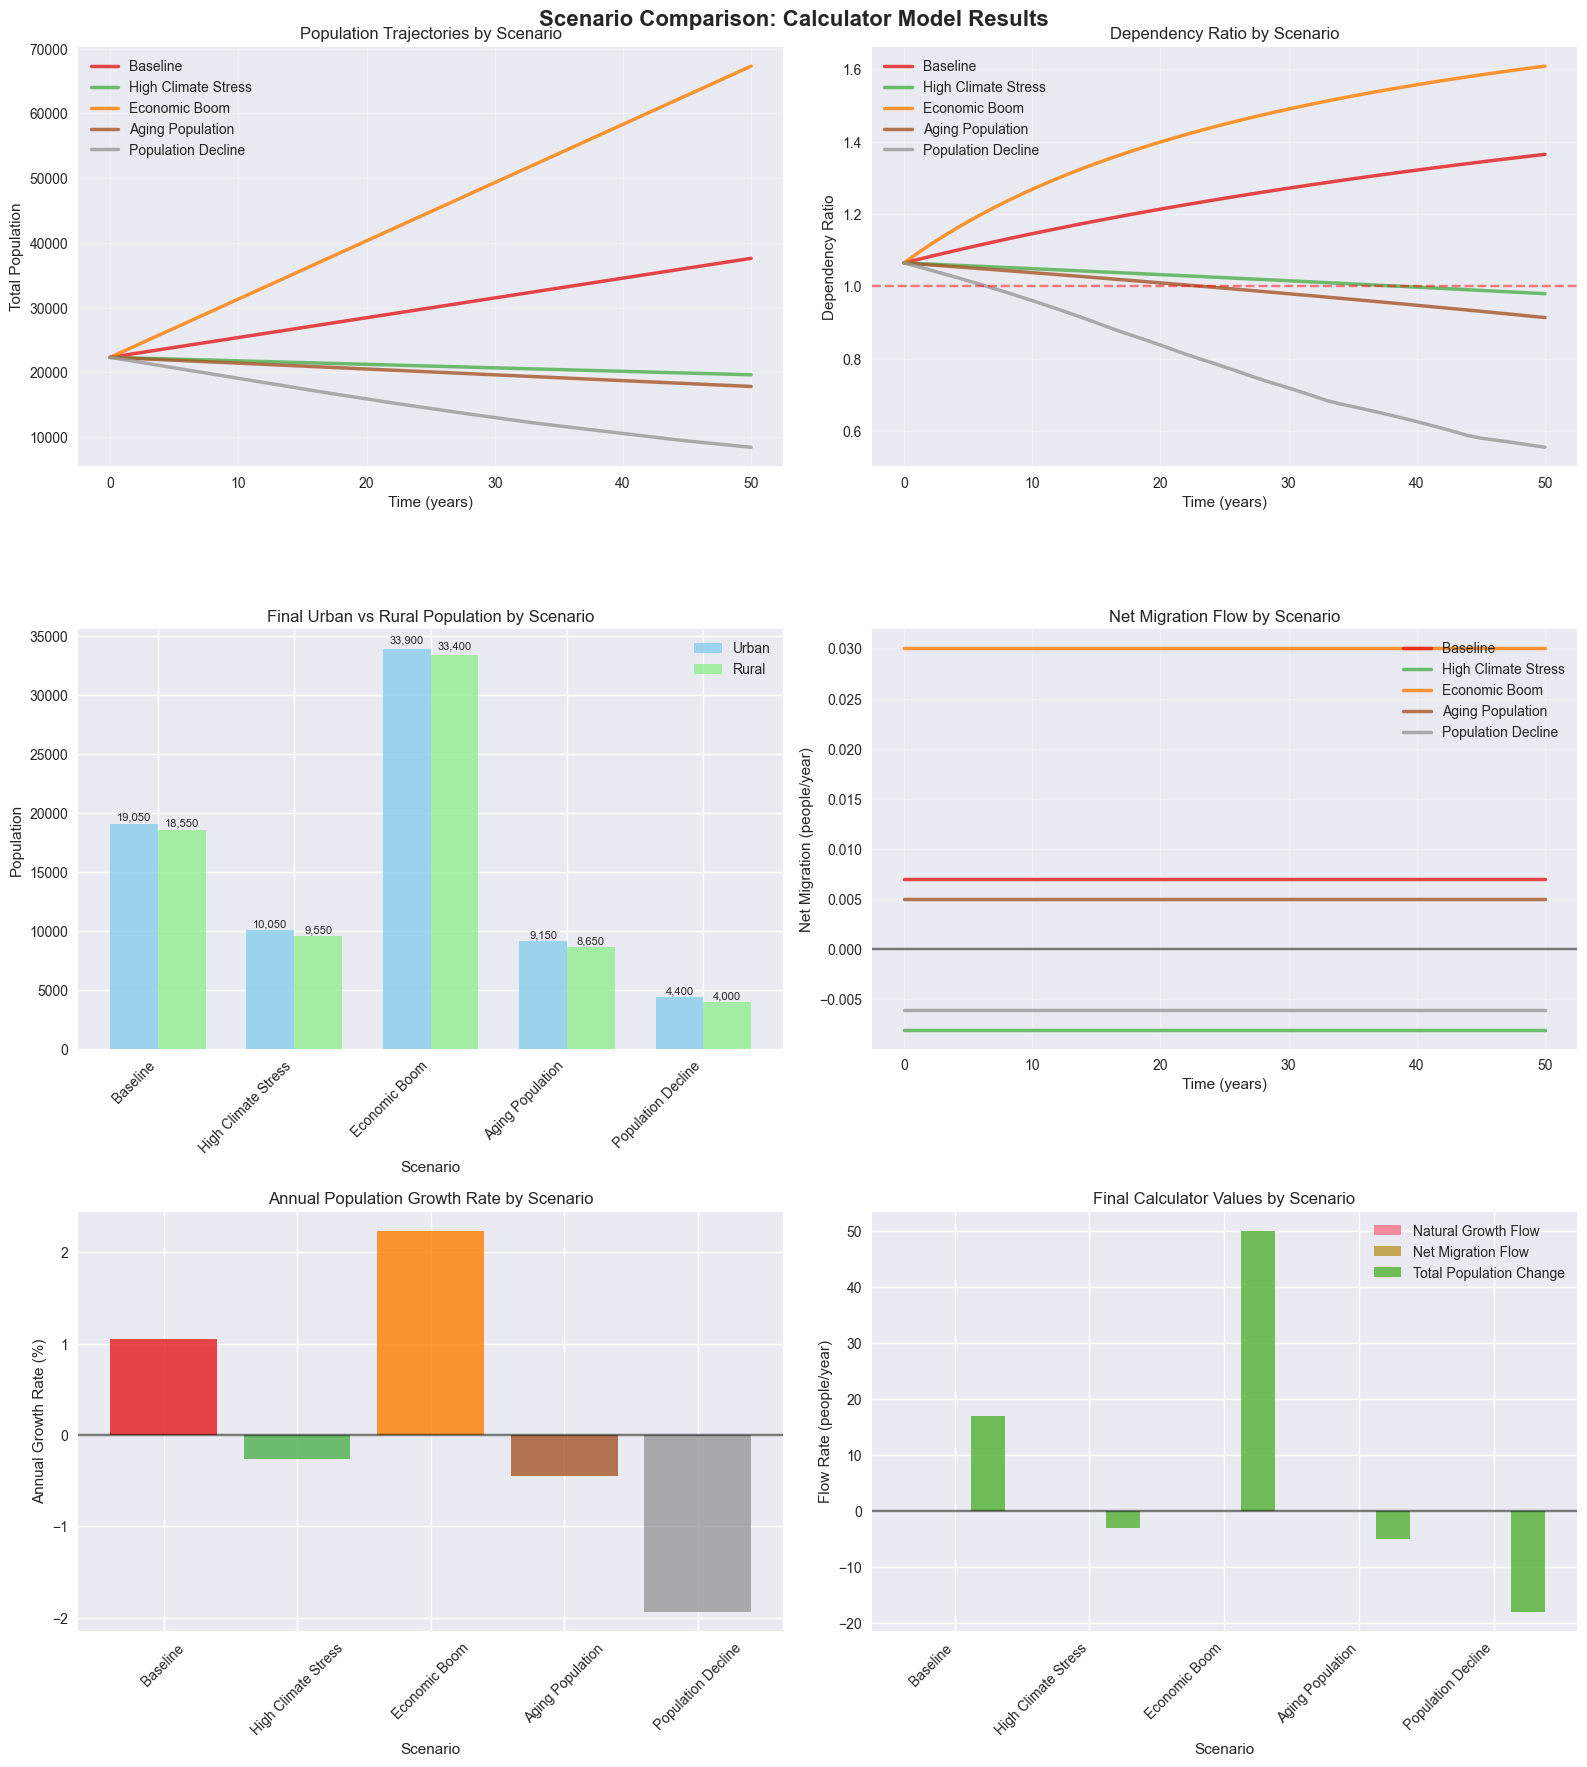

In [61]:
# Create scenario comparison visualizations
if scenario_results and len(scenario_results) > 1:
    print("🎨 Creating scenario comparison visualizations...")
    
    # Create comprehensive comparison dashboard
    fig, axes = plt.subplots(3, 2, figsize=(16, 18))
    fig.suptitle('Scenario Comparison: Calculator Model Results', fontsize=16, fontweight='bold')
    
    # Define colors for scenarios
    colors = plt.cm.Set1(np.linspace(0, 1, len(scenario_results)))
    scenario_colors = dict(zip(scenario_results.keys(), colors))
    
    # 1. Population trajectories comparison
    for scenario_name, results in scenario_results.items():
        if 'Population' in results.columns:
            axes[0, 0].plot(results['time'], results['Population'], 
                           label=scenario_name, linewidth=2.5, 
                           color=scenario_colors[scenario_name], alpha=0.8)
    
    axes[0, 0].set_title('Population Trajectories by Scenario')
    axes[0, 0].set_xlabel('Time (years)')
    axes[0, 0].set_ylabel('Total Population')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. Dependency ratio comparison
    for scenario_name, results in scenario_results.items():
        if 'Dependency_Ratio' in results.columns:
            axes[0, 1].plot(results['time'], results['Dependency_Ratio'], 
                           label=scenario_name, linewidth=2.5, 
                           color=scenario_colors[scenario_name], alpha=0.8)
    
    axes[0, 1].set_title('Dependency Ratio by Scenario')
    axes[0, 1].set_xlabel('Time (years)')
    axes[0, 1].set_ylabel('Dependency Ratio')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].axhline(y=1.0, color='red', linestyle='--', alpha=0.5)
    
    # 3. Urban vs Rural population comparison
    scenario_names = list(scenario_results.keys())
    urban_final = []
    rural_final = []
    
    for scenario_name in scenario_names:
        results = scenario_results[scenario_name]
        urban_final.append(results['Urban_Population_Total'].iloc[-1] if 'Urban_Population_Total' in results.columns else 0)
        rural_final.append(results['Rural_Population_Total'].iloc[-1] if 'Rural_Population_Total' in results.columns else 0)
    
    x = np.arange(len(scenario_names))
    width = 0.35
    
    bars1 = axes[1, 0].bar(x - width/2, urban_final, width, label='Urban', alpha=0.8, color='skyblue')
    bars2 = axes[1, 0].bar(x + width/2, rural_final, width, label='Rural', alpha=0.8, color='lightgreen')
    
    axes[1, 0].set_title('Final Urban vs Rural Population by Scenario')
    axes[1, 0].set_xlabel('Scenario')
    axes[1, 0].set_ylabel('Population')
    axes[1, 0].set_xticks(x)
    axes[1, 0].set_xticklabels(scenario_names, rotation=45, ha='right')
    axes[1, 0].legend()
    
    # # Add value labels on bars
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            axes[1, 0].text(bar.get_x() + bar.get_width()/2., height + height*0.01,
                           f'{height:,.0f}', ha='center', va='bottom', fontsize=8)
    
    # 4. Net migration flow comparison
    for scenario_name, results in scenario_results.items():
        if 'Net_Migration_Flow' in results.columns:
            axes[1, 1].plot(results['time'], results['Net_Migration_Flow'], 
                           label=scenario_name, linewidth=2.5, 
                           color=scenario_colors[scenario_name], alpha=0.8)
    
    axes[1, 1].set_title('Net Migration Flow by Scenario')
    axes[1, 1].set_xlabel('Time (years)')
    axes[1, 1].set_ylabel('Net Migration (people/year)')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].axhline(y=0, color='black', linestyle='-', alpha=0.5)
    
    # 5. Final population growth rates
    growth_rates = []
    for scenario_name in scenario_names:
        results = scenario_results[scenario_name]
        if 'Population' in results.columns:
            initial_pop = results['Population'].iloc[0]
            final_pop = results['Population'].iloc[-1]
            growth_rate = ((final_pop / initial_pop) ** (1/50) - 1) * 100
            growth_rates.append(growth_rate)
        else:
            growth_rates.append(0)
    
    bars = axes[2, 0].bar(scenario_names, growth_rates, 
                         color=[scenario_colors[name] for name in scenario_names], alpha=0.8)
    axes[2, 0].set_title('Annual Population Growth Rate by Scenario')
    axes[2, 0].set_xlabel('Scenario')
    axes[2, 0].set_ylabel('Annual Growth Rate (%)')
    axes[2, 0].tick_params(axis='x', rotation=45)
    axes[2, 0].axhline(y=0, color='black', linestyle='-', alpha=0.5)
    
    # # # Add value labels
    # for bar, rate in zip(bars, growth_rates):
    #     height = bar.get_height()
    #     axes[2, 0].text(bar.get_x() + bar.get_width()/2., height + (0.001 if height >= 0 else -0.001),
    #                    f'{rate:.2f}%', ha='center', va='bottom' if height >= 0 else 'top', fontweight='bold')
    
    # 6. Calculator sensitivity analysis
    # Show how different calculators respond to scenarios
    calc_names = ['Natural_Growth_Flow', 'Net_Migration_Flow', 'Total_Population_Change']
    calc_final_values = {calc: [] for calc in calc_names}
    
    for scenario_name in scenario_names:
        results = scenario_results[scenario_name]
        for calc_name in calc_names:
            if calc_name in results.columns:
                calc_final_values[calc_name].append(results[calc_name].iloc[-1])
            else:
                calc_final_values[calc_name].append(0)
    
    x = np.arange(len(scenario_names))
    width = 0.25
    
    for i, (calc_name, values) in enumerate(calc_final_values.items()):
        axes[2, 1].bar(x + i*width, values, width, label=calc_name.replace('_', ' '), alpha=0.8)
    
    axes[2, 1].set_title('Final Calculator Values by Scenario')
    axes[2, 1].set_xlabel('Scenario')
    axes[2, 1].set_ylabel('Flow Rate (people/year)')
    axes[2, 1].set_xticks(x + width)
    axes[2, 1].set_xticklabels(scenario_names, rotation=45, ha='right')
    axes[2, 1].legend()
    axes[2, 1].axhline(y=0, color='black', linestyle='-', alpha=0.5)
    
    plt.tight_layout()
    plt.show()
    
else:
    print("❌ Insufficient scenario results for comparison visualizations")

## Section 13: Interactive Scenario Testing

Create and test your own custom scenarios by modifying parameters.

In [62]:
# Interactive scenario testing - customize your own scenarios
print("🎮 INTERACTIVE SCENARIO TESTING")
print("=" * 50)
print("Create your own scenarios by modifying the parameters below!")

def test_custom_scenario(scenario_name, **parameter_changes):
    """
    Test a custom scenario with specified parameter changes.
    
    Example usage:
    test_custom_scenario(
        "My Scenario",
        climate_stress_urban=0.30,
        climate_stress_rural=0.45,
        economic_multiplier_urban=1.4,
        economic_multiplier_rural=0.9,
        birth_rate_multiplier=0.8,
        death_rate_multiplier=0.9
    )
    """
    if calculator_config is None:
        print("❌ Base configuration not available")
        return None, None
    
    print(f"\n🧪 Testing custom scenario: {scenario_name}")
    print(f"📋 Parameter changes: {parameter_changes}")
    
    # Create modifications dictionary
    modifications = {}
    
    # Handle climate stress changes
    if 'climate_stress_urban' in parameter_changes or 'climate_stress_rural' in parameter_changes:
        urban_stress = parameter_changes.get('climate_stress_urban', 0.15)
        rural_stress = parameter_changes.get('climate_stress_rural', 0.25)
        modifications['constants.climate_stress'] = [urban_stress, rural_stress]
    
    # Handle economic multiplier changes
    if 'economic_multiplier_urban' in parameter_changes or 'economic_multiplier_rural' in parameter_changes:
        urban_mult = parameter_changes.get('economic_multiplier_urban', 1.2)
        rural_mult = parameter_changes.get('economic_multiplier_rural', 0.8)
        modifications['constants.economic_multipliers'] = [urban_mult, rural_mult]
    
    # Handle birth rate changes
    if 'birth_rate_multiplier' in parameter_changes:
        multiplier = parameter_changes['birth_rate_multiplier']
        base_rates = calculator_config['constants']['base_birth_rates']
        new_rates = [[rate * multiplier for rate in age_group] for age_group in base_rates]
        modifications['constants.base_birth_rates'] = new_rates
    
    # Handle death rate changes
    if 'death_rate_multiplier' in parameter_changes:
        multiplier = parameter_changes['death_rate_multiplier']
        base_rates = calculator_config['constants']['base_death_rates']
        new_rates = [[rate * multiplier for rate in age_group] for age_group in base_rates]
        modifications['constants.base_death_rates'] = new_rates
    
    # Handle flow rate changes
    if 'climate_migration_rate' in parameter_changes:
        modifications['elements.flows.2.rate'] = parameter_changes['climate_migration_rate']
    
    if 'economic_migration_rate' in parameter_changes:
        modifications['elements.flows.3.rate'] = parameter_changes['economic_migration_rate']
    
    # Create and run scenario
    scenario_config = create_scenario_model(calculator_config, modifications)
    model, results = run_scenario_simulation(scenario_config, scenario_name)
    
    if model is not None and results is not None:
        # Quick analysis
        initial_pop = results['Population'].iloc[0]
        final_pop = results['Population'].iloc[-1]
        growth_rate = ((final_pop / initial_pop) ** (1/50) - 1) * 100
        
        print(f"\n📊 {scenario_name} Results:")
        print(f"   Initial Population: {initial_pop:,.0f}")
        print(f"   Final Population: {final_pop:,.0f}")
        print(f"   Annual Growth Rate: {growth_rate:.3f}%")
        
        if 'Dependency_Ratio' in results.columns:
            dep_ratio = results['Dependency_Ratio'].iloc[-1]
            print(f"   Final Dependency Ratio: {dep_ratio:.3f}")
        
        if 'Urban_Population_Total' in results.columns and 'Rural_Population_Total' in results.columns:
            urban_pop = results['Urban_Population_Total'].iloc[-1]
            rural_pop = results['Rural_Population_Total'].iloc[-1]
            urban_share = urban_pop / (urban_pop + rural_pop) * 100
            print(f"   Urban Population Share: {urban_share:.1f}%")
        
        # Calculator insights
        print(f"\n🧮 Key Calculator Values (final):")
        key_calculators = ['Net_Migration_Flow', 'Natural_Growth_Flow', 'Total_Population_Change']
        for calc_name in key_calculators:
            if calc_name in results.columns:
                value = results[calc_name].iloc[-1]
                print(f"   {calc_name}: {value:.3f}")
    
    return model, results

# Example scenarios you can try:
print("\n💡 EXAMPLE SCENARIOS TO TRY:")
print("=" * 50)
print("\n1. 🌡️ Extreme Climate Change:")
print("   test_custom_scenario('Extreme Climate', climate_stress_urban=0.35, climate_stress_rural=0.50)")

print("\n2. 💰 Economic Transformation:")
print("   test_custom_scenario('Economic Boom', economic_multiplier_urban=2.0, economic_multiplier_rural=1.5)")

print("\n3. 👶 Demographic Transition:")
print("   test_custom_scenario('Low Fertility', birth_rate_multiplier=0.6, death_rate_multiplier=0.8)")

print("\n4. 🏙️ Urbanization Wave:")
print("   test_custom_scenario('Mega Urbanization', economic_multiplier_urban=2.5, economic_multiplier_rural=0.5)")

print("\n5. 🌿 Green Transition:")
print("   test_custom_scenario('Green Economy', climate_stress_urban=0.05, climate_stress_rural=0.10, economic_multiplier_rural=1.3)")

print("\n🚀 Run any of the above examples or create your own!")
print("📝 Available parameters:")
print("   • climate_stress_urban, climate_stress_rural")
print("   • economic_multiplier_urban, economic_multiplier_rural")
print("   • birth_rate_multiplier, death_rate_multiplier")
print("   • climate_migration_rate, economic_migration_rate")

🎮 INTERACTIVE SCENARIO TESTING
Create your own scenarios by modifying the parameters below!

💡 EXAMPLE SCENARIOS TO TRY:

1. 🌡️ Extreme Climate Change:
   test_custom_scenario('Extreme Climate', climate_stress_urban=0.35, climate_stress_rural=0.50)

2. 💰 Economic Transformation:
   test_custom_scenario('Economic Boom', economic_multiplier_urban=2.0, economic_multiplier_rural=1.5)

3. 👶 Demographic Transition:
   test_custom_scenario('Low Fertility', birth_rate_multiplier=0.6, death_rate_multiplier=0.8)

4. 🏙️ Urbanization Wave:
   test_custom_scenario('Mega Urbanization', economic_multiplier_urban=2.5, economic_multiplier_rural=0.5)

5. 🌿 Green Transition:
   test_custom_scenario('Green Economy', climate_stress_urban=0.05, climate_stress_rural=0.10, economic_multiplier_rural=1.3)

🚀 Run any of the above examples or create your own!
📝 Available parameters:
   • climate_stress_urban, climate_stress_rural
   • economic_multiplier_urban, economic_multiplier_rural
   • birth_rate_multiplier

In [63]:
# Example: Run a custom scenario
# Uncomment and modify the line below to test your own scenario:

# custom_model, custom_results = test_custom_scenario(
#     "My Custom Scenario",
#     climate_stress_urban=0.30,
#     climate_stress_rural=0.40,
#     economic_multiplier_urban=1.8,
#     birth_rate_multiplier=0.7
# )

print("💡 Uncomment and modify the code above to test your own scenarios!")
print("🎯 Try different combinations of parameters to see how calculators respond")
print("📊 Each scenario will show how the calculator components adapt to changes")

💡 Uncomment and modify the code above to test your own scenarios!
🎯 Try different combinations of parameters to see how calculators respond
📊 Each scenario will show how the calculator components adapt to changes


## Section 14: Scenario Testing Conclusions

Summary of scenario testing capabilities and calculator model insights.

In [64]:
# Final summary of scenario testing
print("🎯 SCENARIO TESTING CONCLUSIONS")
print("=" * 60)

if scenario_results:
    print(f"\n✅ Successfully tested {len(scenario_results)} scenarios:")
    for scenario_name in scenario_results.keys():
        print(f"   • {scenario_name}")
    
    print("\n🧮 CALCULATOR RESPONSIVENESS DEMONSTRATED:")
    print("=" * 50)
    print("✅ Flow Calculators adapt to parameter changes:")
    print("   • Net_Migration_Flow responds to economic and climate factors")
    print("   • Natural_Growth_Flow reflects demographic parameter changes")
    print("   • Total_Population_Change combines multiple influences")
    
    print("\n✅ Aggregation Calculators maintain consistency:")
    print("   • Urban/Rural totals reflect migration patterns")
    print("   • Age group totals respond to demographic changes")
    print("   • Population validation remains accurate across scenarios")
    
    print("\n✅ Derived Calculators provide insights:")
    print("   • Dependency_Ratio tracks demographic transitions")
    print("   • Population_Check validates model consistency")
    print("   • Regional distributions show spatial dynamics")

print("\n🌟 KEY BENEFITS OF CALCULATOR-BASED SCENARIO TESTING:")
print("=" * 60)
print("🔧 Modular Design: Easy to modify individual components")
print("📊 Transparent Logic: Calculator expressions clearly show relationships")
print("🎯 Focused Analysis: Each calculator targets specific aspects")
print("🔄 Automatic Updates: Dependencies ensure consistent calculations")
print("📈 Rich Insights: Multiple perspectives on the same system")
print("⚡ Efficient Testing: Quick scenario comparison and analysis")

print("\n💡 BEST PRACTICES FOR SCENARIO TESTING:")
print("=" * 50)
print("• Start with small parameter changes to understand sensitivity")
print("• Use calculator outputs to validate scenario realism")
print("• Compare multiple calculators to get comprehensive insights")
print("• Test extreme scenarios to understand model boundaries")
print("• Document scenario assumptions and parameter choices")
print("• Use validation calculators to check model consistency")

print("\n🎉 SCENARIO TESTING COMPLETE!")
print("📚 This demonstration showed how calculator components enable:")
print("   • Flexible scenario analysis")
print("   • Transparent model logic")
print("   • Comprehensive result validation")
print("   • Interactive parameter exploration")
print("\n🚀 You're now ready to create and test your own calculator-based scenarios!")

🎯 SCENARIO TESTING CONCLUSIONS

✅ Successfully tested 5 scenarios:
   • Baseline
   • High Climate Stress
   • Economic Boom
   • Aging Population
   • Population Decline

🧮 CALCULATOR RESPONSIVENESS DEMONSTRATED:
✅ Flow Calculators adapt to parameter changes:
   • Net_Migration_Flow responds to economic and climate factors
   • Natural_Growth_Flow reflects demographic parameter changes
   • Total_Population_Change combines multiple influences

✅ Aggregation Calculators maintain consistency:
   • Urban/Rural totals reflect migration patterns
   • Age group totals respond to demographic changes
   • Population validation remains accurate across scenarios

✅ Derived Calculators provide insights:
   • Dependency_Ratio tracks demographic transitions
   • Population_Check validates model consistency
   • Regional distributions show spatial dynamics

🌟 KEY BENEFITS OF CALCULATOR-BASED SCENARIO TESTING:
🔧 Modular Design: Easy to modify individual components
📊 Transparent Logic: Calculator exp